# Análise de Desempenho Educacional - MA

> Objetivo: segmentar municípios por contexto socioeconômico e, dentro de cada grupo, identificar fatores associados aos destaques de IDEB.

Este notebook está alinhado com o script `src/analytics.py` e organizado em passos curtos.

Fluxo da análise:
1. Carregamento e checagem dos dados
2. Diagnóstico de clusterização (Elbow, Silhouette, PCA)
3. Clusterização final (k=2) e descrição dos grupos
4. Relevância de variáveis para diferenciar destaques no IDEB por cluster
5. Comparação de perfis e testes de Mann-Whitney
6. Gráficos finais para relatório

## 1) Carregamento e pré-processamento

> Neste passo você confere a base consolidada e prepara as variáveis para clustering.

Observação metodológica:
- Os clusters são formados apenas com variáveis socioeconômicas (`RENDA_PER_CAPITA_2010` e `IDHM_2010`).
- IDEB e demais variáveis entram depois para interpretação intracluster.

In [2]:
import importlib
import pandas as pd
import analytics

importlib.reload(analytics)

print('Arquivo de entrada:', analytics.TRUSTED_DIR / 'indicadores_municipais_ma.csv')
df = analytics.carregar_dados()

print('Shape:', df.shape)
print('Municipios unicos:', df['NO_MUNICIPIO'].nunique())
print('\nVariaveis de cluster (socioeconomicas):', analytics.VARS_CLUSTER)
print('\nNulos nas variaveis de cluster:')
print(df[analytics.VARS_CLUSTER].isna().sum())

df[['NO_MUNICIPIO', 'RENDA_PER_CAPITA_2010', 'IDHM_2010', 'VL_OBSERVADO_2023']].head()

Arquivo de entrada: /media/dados/aplicacoes/git/mestrado/Artigos/desempenho-educacional-maranhao/data/trusted/indicadores_municipais_ma.csv
Shape: (217, 41)
Municipios unicos: 217

Variaveis de cluster (socioeconomicas): ['RENDA_PER_CAPITA_2010', 'IDHM_2010']

Nulos nas variaveis de cluster:
RENDA_PER_CAPITA_2010    0
IDHM_2010                0
dtype: int64


,NO_MUNICIPIO,RENDA_PER_CAPITA_2010,IDHM_2010,VL_OBSERVADO_2023
0,AÇAILÂNDIA,438.56,0.785,5.5
1,AFONSO CUNHA,149.78,0.725,5.7
2,ÁGUA DOCE DO MARANHÃO,172.55,0.697,4.6
3,ALCÂNTARA,209.27,0.753,4.4
4,ALDEIAS ALTAS,179.92,0.720,4.3


## 2) Diagnóstico de clusters

> Avalia diferentes valores de `k` e visualiza a separação dos grupos.

Leitura esperada:
- Elbow/Silhouette ajudam a justificar o número de clusters.
- PCA mostra se os grupos estão visualmente separáveis.

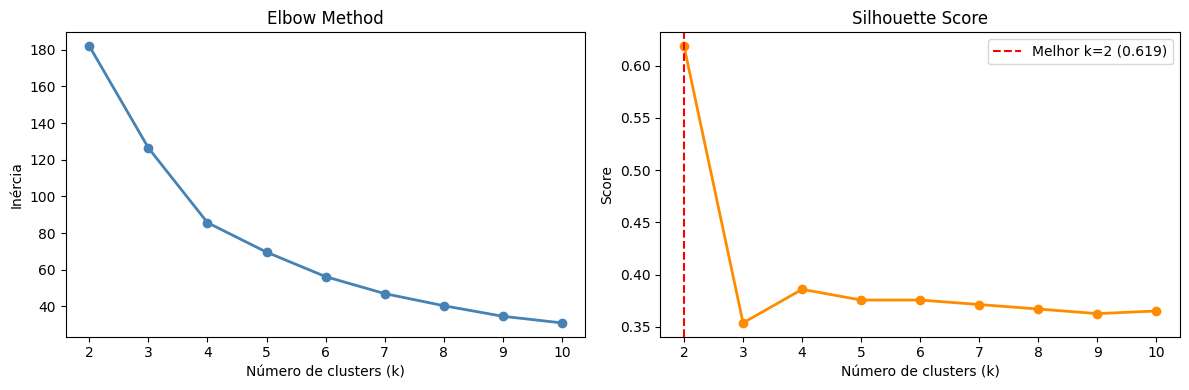


Melhor k pelo Silhouette: 2 (score: 0.619)

Todos os scores:
  k=2: 0.619
  k=3: 0.354
  k=4: 0.386
  k=5: 0.376
  k=6: 0.376
  k=7: 0.371
  k=8: 0.367
  k=9: 0.363
  k=10: 0.365


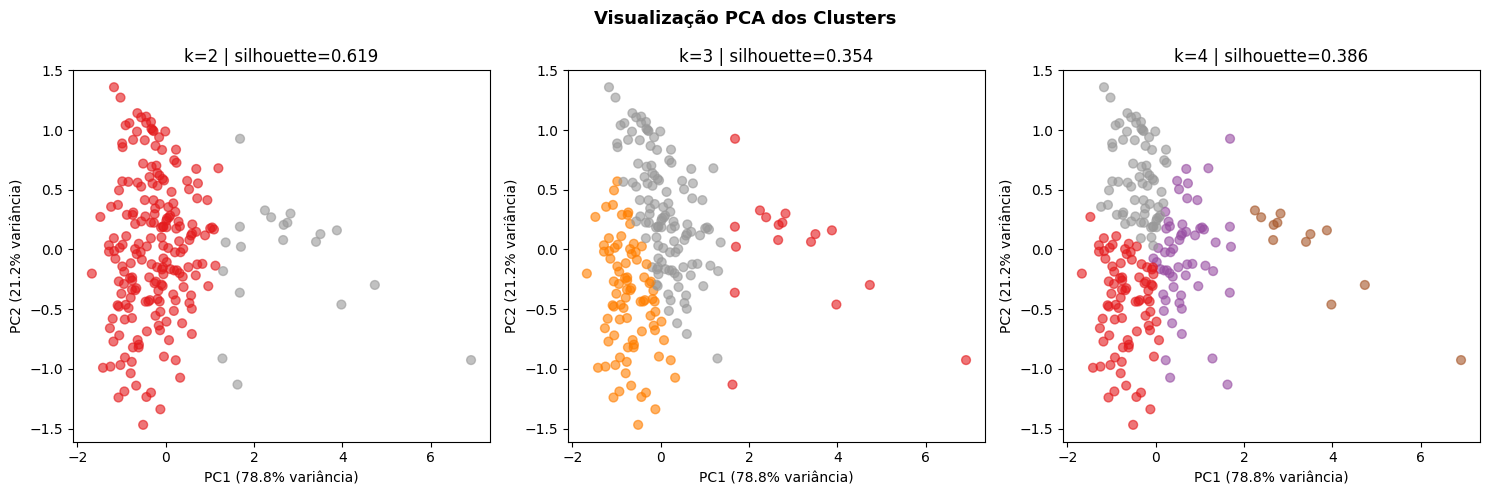


Valor configurado no pipeline para cluster final: 2


In [3]:
X_scaled, _ = analytics.normalizar(df)
k_range = range(2, 11)

# Grafico Elbow + Silhouette (mostra em tela)
silhouettes = analytics.elbow_silhouette(X_scaled, k_range, salvar_arquivo=False)

# Visualizacao em PCA para k=2,3,4
analytics.visualizar_pca(X_scaled, silhouettes, k_range, salvar_arquivo=False)

print('\nValor configurado no pipeline para cluster final:', analytics.CLUSTER_K)

## 3) Clusterização final e leitura dos grupos

> Executa a clusterização final (`k=2`) e lista os municípios destaque por IDEB em cada cluster.

Interpretação:
- `vulneráveis`: grupo com menor renda média
- `maior renda`: grupo com melhor contexto socioeconômico médio

In [4]:
df_cluster = analytics.clusterizar(df.copy(), X_scaled, k=analytics.CLUSTER_K)

# Top e bottom IDEB dentro de cada cluster
analytics.destacar_municipios_por_cluster(df_cluster, top_n=5)

# Outliers positivos por cluster
analytics.outliers_positivos(df_cluster)


Tamanho dos clusters:
CLUSTER_NOME
vulneráveis    197
maior renda     20
dtype: int64

Cluster vulneráveis — municípios (197):
                NO_MUNICIPIO  RENDA_PER_CAPITA_2010  VL_OBSERVADO_2023
                      CAXIAS                 324.90                5.2
             RIBAMAR FIQUENE                 317.75                5.1
     GOVERNADOR EDISON LOBÃO                 312.56                4.6
                       ARARI                 308.83                6.0
              BARRA DO CORDA                 305.61                5.1
                 JOÃO LISBOA                 303.91                5.3
        SANTA LUZIA DO PARUÁ                 301.39                4.9
SÃO RAIMUNDO DAS MANGABEIRAS                 301.25                5.2
                   DOM PEDRO                 298.33                5.7
                     MATINHA                 294.51                4.8
                    PINHEIRO                 292.88                5.1
             BARÃO D

## 4) Variáveis mais relevantes para diferenciar destaques no IDEB

> Aqui a pergunta é: dentro de cada cluster, o que diferencia os municípios de IDEB alto vs baixo?

> Método padronizado no notebook:
- recorte por quantis (25% melhores vs 25% piores)
- Random Forest Classifier + filtro de significância (Mann-Whitney p < 0.10)

In [5]:
# Relevancia das variaveis para a propria formacao dos clusters (socioeconomicas)
_ = analytics.relevancia_variaveis_cluster(X_scaled, k=analytics.CLUSTER_K, n_bootstrap=25)

# Relevancia de variaveis para diferenciar alto vs baixo IDEB dentro do cluster
analytics.variaveis_relevantes_por_cluster(
    df_cluster,
    salvar_arquivo=False,
    q=0.25,
    min_amostras_por_grupo=10,
 )


RELEVÂNCIA DE VARIÁVEIS PARA CLUSTERIZAÇÃO (ABLAÇÃO)
Silhouette base (k=2): 0.619
Estabilidade base (ARI bootstrap): 0.765

Quanto maior o score_relevancia, mais a variável contribui para os clusters.
             variavel  delta_silhouette  delta_estabilidade  ari_vs_base  score_relevancia
RENDA_PER_CAPITA_2010            0.0456              0.7426       0.0111            1.7771
            IDHM_2010           -0.0985              0.0195       1.0000            0.0195

VARIÁVEIS MAIS RELEVANTES PARA DIFERENCIAR DESTAQUES NO IDEB

Cluster vulneráveis | alto=57 | baixo=50 | corte quantil=25%
Top 8 variáveis para diferenciar alto vs baixo IDEB no cluster:
                               variavel  importancia_rf  delta_alto_menos_baixo             direcao  p_valor_mw sig
                  RENDA_PER_CAPITA_2010          0.1214                 24.5614 maior_nos_destaques      0.0104  **
             MEDIA_ALUNOS_POR_TURMA_BAS          0.0983                  1.0342 maior_nos_destaques      

## 5) Comparação de perfis e testes estatísticos

> Este bloco usa o mesmo recorte por quantis para manter coerência com as sugestões de melhoria.

Saídas:
- médias por perfil (alto/médio/baixo) dentro de cada cluster
- p-valores do teste Mann-Whitney para cada variável explicativa

In [6]:
analytics.comparar_perfis(df_cluster, q=0.25)
analytics.mann_whitney(df_cluster, q=0.25)


Distribuição por perfil — Cluster vulneráveis (quantil 25%):
PERFIL
médio    90
alto     57
baixo    50
Name: count, dtype: int64

Perfil médio por grupo (Cluster vulneráveis):
PERFIL                                     alto   baixo   médio
VL_OBSERVADO_2023                          5.65    4.35    4.87
RENDA_PER_CAPITA_2010                    215.07  190.50  217.53
IDHM_2010                                  0.74    0.74    0.73
PCT_ESCOLAS_COM_INTERNET                  76.19   68.60   74.92
PCT_ESCOLAS_COM_BIBLIOTECA_LEITURA        13.74   10.42   12.91
PCT_ESCOLAS_COM_LAB_INFORMATICA            4.81    5.76    5.66
PCT_ESCOLAS_COM_QUADRA                     7.45    6.37    7.07
PCT_ESCOLAS_COM_AGUA_ADEQUADA             77.65   78.30   82.28
PCT_ESCOLAS_COM_ESGOTO_ADEQUADO           49.42   41.84   48.76
PCT_DOC_SUPERIOR_COMPLETO                 64.70   56.38   60.13
PCT_DOC_LICENCIATURA_TOTAL                63.93   55.29   58.70
MEDIA_ALUNOS_POR_TURMA_BAS                18.88   17.8

## 6) Gráficos finais (para relatório e apresentação)

> Este bloco gera e exibe os gráficos principais: distribuição do IDEB e importância global de variáveis.

Se quiser salvar todos os gráficos em `reports/figures`, execute a célula 7 com `salvar_graficos=True` no final.

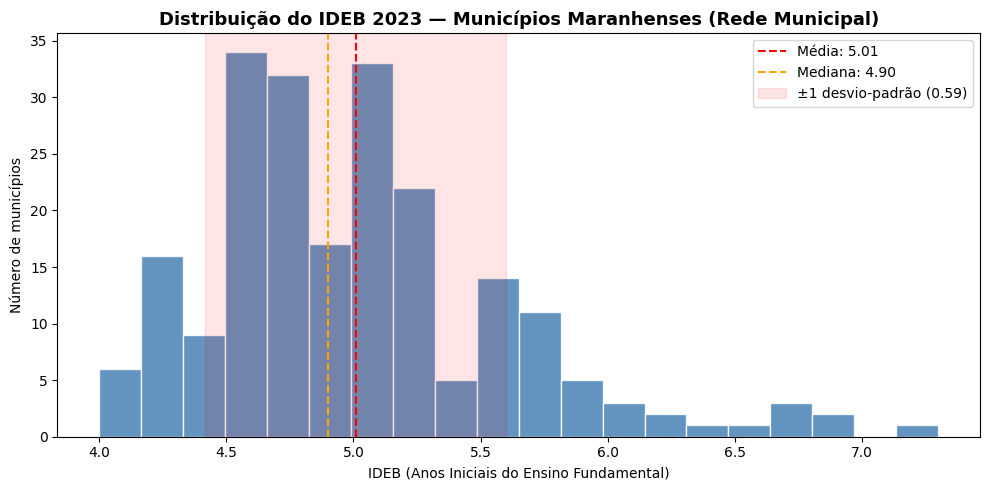


Distribuição do IDEB 2023:
  Municípios com dado: 217
  Média:   5.01
  Mediana: 4.90
  Desvio-padrão: 0.59
  Min: 4.00  |  Max: 7.30

RANDOM FOREST — Importância de variáveis

R² no treino: 0.850

Importância das variáveis (ordem decrescente):
  PCT_DOC_COM_SUPERIOR                          0.394  ███████████████████████████████████████
  RENDA_PER_CAPITA_2010                         0.355  ███████████████████████████████████
  IDHM_2010                                     0.250  █████████████████████████


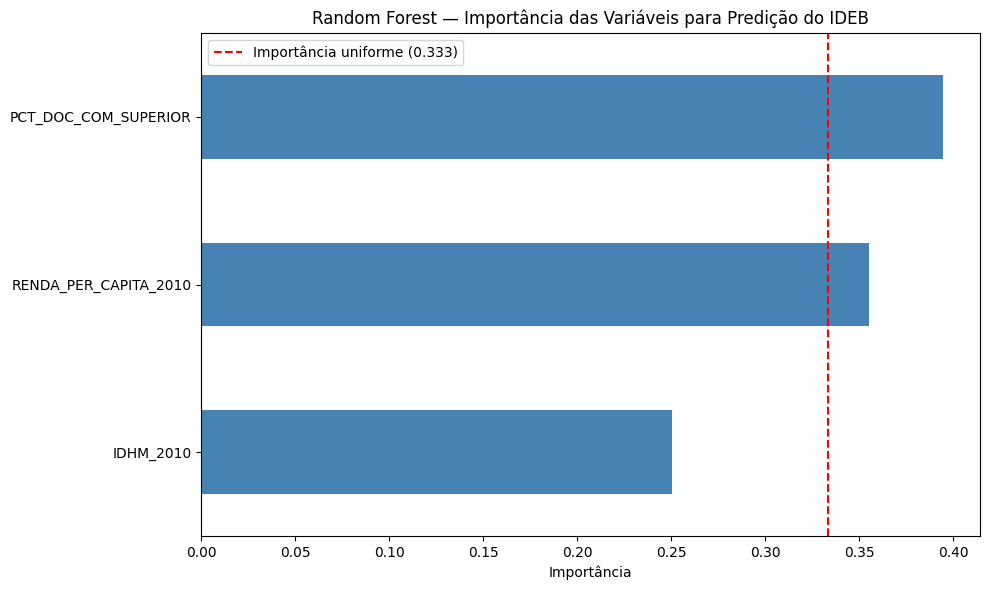

In [7]:
analytics.distribuicao_ideb(df_cluster, salvar_arquivo=False)
analytics.random_forest(df_cluster, salvar_arquivo=False)

# Opcional: rodar pipeline completo de uma vez e salvar figuras
# analytics.main(salvar_graficos=True)

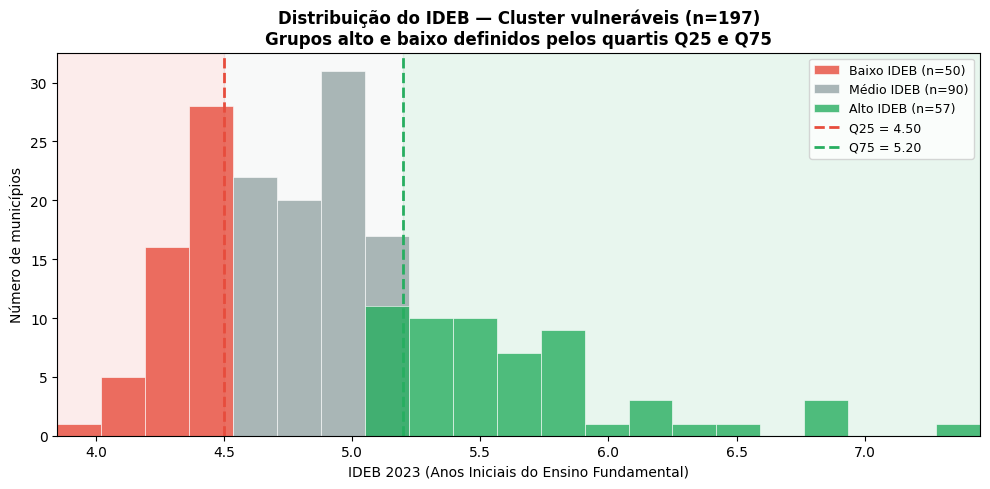


Distribuição por perfil — Cluster vulneráveis:
  Alto: n=57 | média=5.65 | [5.20–7.30]
  Médio: n=90 | média=4.87 | [4.60–5.10]
  Baixo: n=50 | média=4.35 | [4.00–4.50]


In [8]:
# Distribuição do IDEB no cluster vulnerável com cortes por quartis
# Gerado em: reports/figures/distribuicao_quartis_vulneraveis.png
analytics.distribuicao_quartis_cluster(df_cluster, cluster_nome='vulneráveis', q=0.25, salvar_arquivo=False)